Generating Graded Interface Heatmap...
Saved: heatmap_sharp.pdf
Saved: heatmap_graded.pdf
Done! Check 'heatmap_graded.pdf'


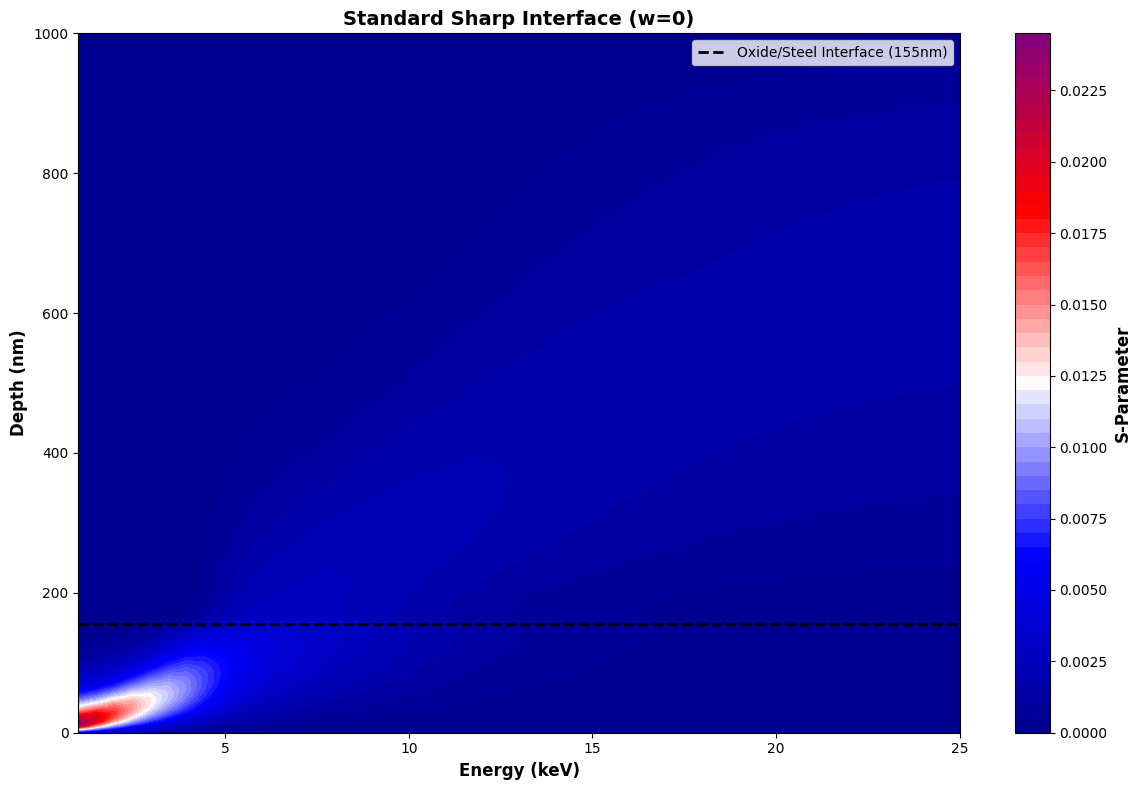

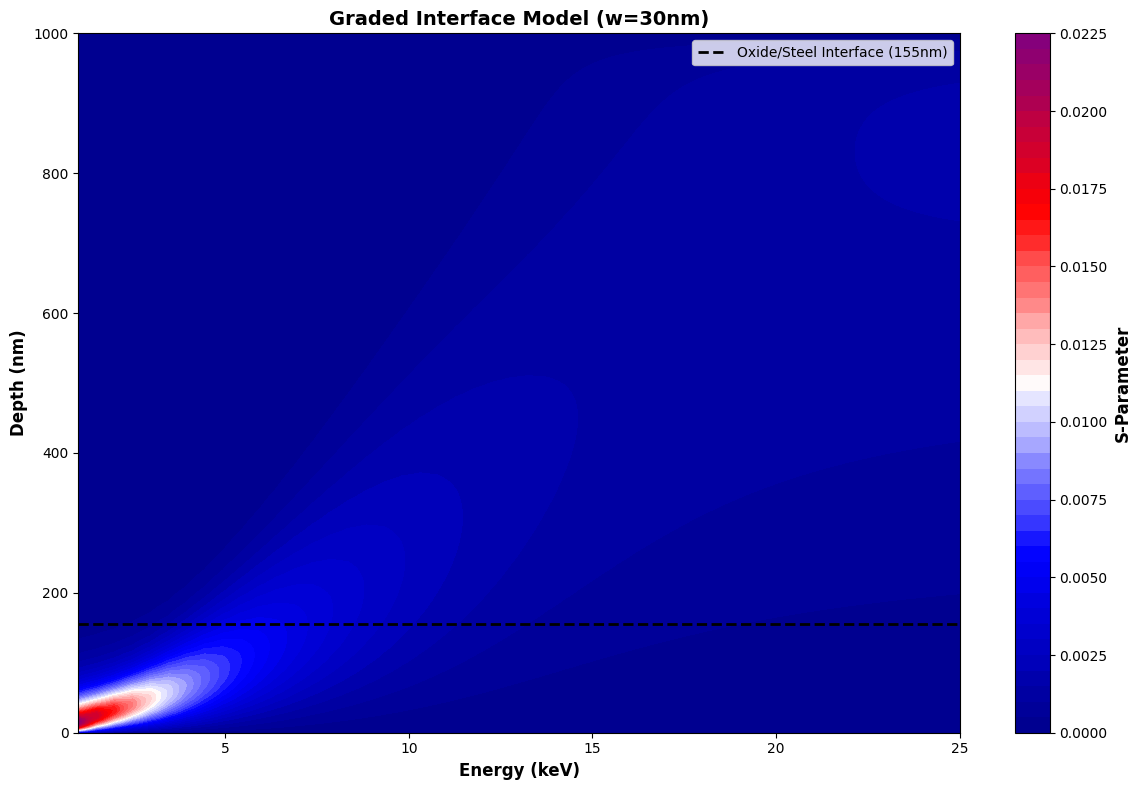

In [1]:
import sys
sys.path.insert(0, r'C:\Users\jeanv\OneDrive - Delft University of Technology\Uitwisseling - TUDelft\Courses\MEP\Programming')

import numpy as np
import matplotlib.pyplot as plt
from pals_analysis import config
from pals_analysis.physics.implantation import makhov_profile
from pals_analysis.physics.annihilation import calculate_annihilation_profile
from pals_analysis.visualization.plots import create_heatmap

def run_graded_heatmap():
    print("Generating Graded Interface Heatmap...")

    # 1. Setup
    energies = np.linspace(1, 25, 50)
    z_grid = np.linspace(0, 1000, 500)
    
    # Your sample properties
    layers = [
        {'thickness': 10, 'density': 2.50, 'L_diff': 100},
        {'thickness': 155, 'density': 5.24, 'L_diff': 30},
        {'thickness': 30, 'density': 3.50, 'L_diff': 0.001},
        {'thickness': 1000, 'density': 8.00, 'L_diff': 150}
    ]
    
    # 2. Generate Data using the GRADED model
    # We set w=30nm to really see the blurring effect
    matrix_sharp = []
    matrix_graded = []
    
    for E in energies:
        # Run Sharp (Standard)
        p_s = makhov_profile(z_grid, E, layers, model='sharp')
        c_s = calculate_annihilation_profile(z_grid, p_s, layers, model='sharp')
        matrix_sharp.append(c_s)
        
        # Run Graded (New!) - Notice we pass model='graded' and w=30
        p_g = makhov_profile(z_grid, E, layers, model='graded', w=30.0)
        c_g = calculate_annihilation_profile(z_grid, p_g, layers, model='graded', w=30.0)
        matrix_graded.append(c_g)

    # 3. Plotting
    # Heatmap 1: The Sharp Interface (for comparison)
    create_heatmap(
        energies, z_grid, np.array(matrix_sharp),
        title="Standard Sharp Interface (w=0)",
        save_as="heatmap_sharp.pdf",
        d_ox=155
    )
    
    # Heatmap 2: The Graded Interface
    # You should see the interface region look 'fuzzier' and the transition smoother
    create_heatmap(
        energies, z_grid, np.array(matrix_graded),
        title="Graded Interface Model (w=30nm)",
        save_as="heatmap_graded.pdf",
        d_ox=155
    )
    print("Done! Check 'heatmap_graded.pdf'")

if __name__ == "__main__":
    run_graded_heatmap()